   Year  Month              Region                              County  \
0  2012      6  Yorkshire & Humber                     North Yorkshire   
1  2012     12     East of England                       Hertfordshire   
2  2012     10               Wales                    North West Wales   
3  2012      5  Yorkshire & Humber  East Riding and North Lincolnshire   
4  2012      3  Yorkshire & Humber                     North Yorkshire   

  Age Category             Clinical Sign             Diagnosis  Cases  \
0     0-7 Days                   Unknown  Yolk Sack\nInfection      2   
1        Adult              Non-specific       Marek's Disease      1   
2        adult                 Recumbent           Manutrition      1   
3     0-7 Days                   Unknown  Yolk Sack\nInfection      1   
4        Adult  Musculoskeletal&/or Lame       Marek's Disease      1   

   Temparature  Poultry Density  Outbreak Logistics Regression  
0         15.1             55.2                    

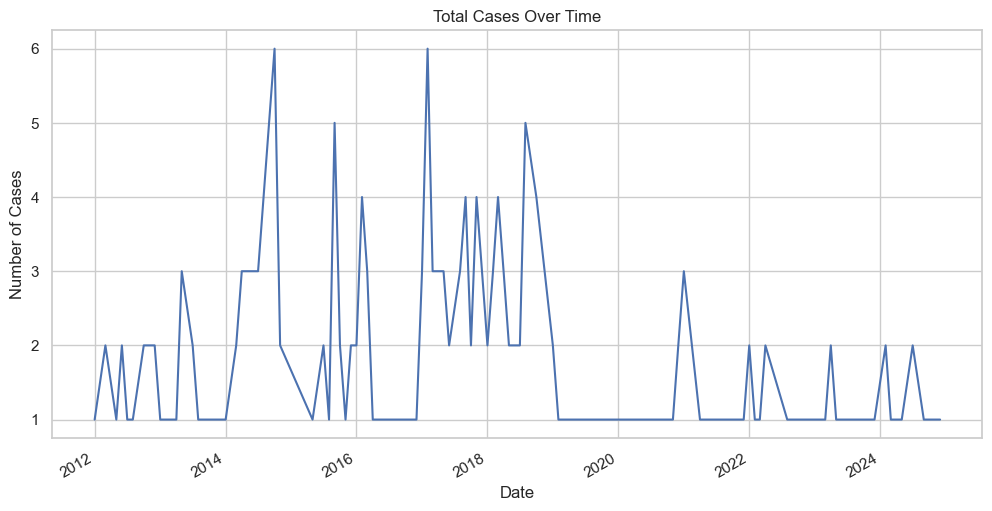

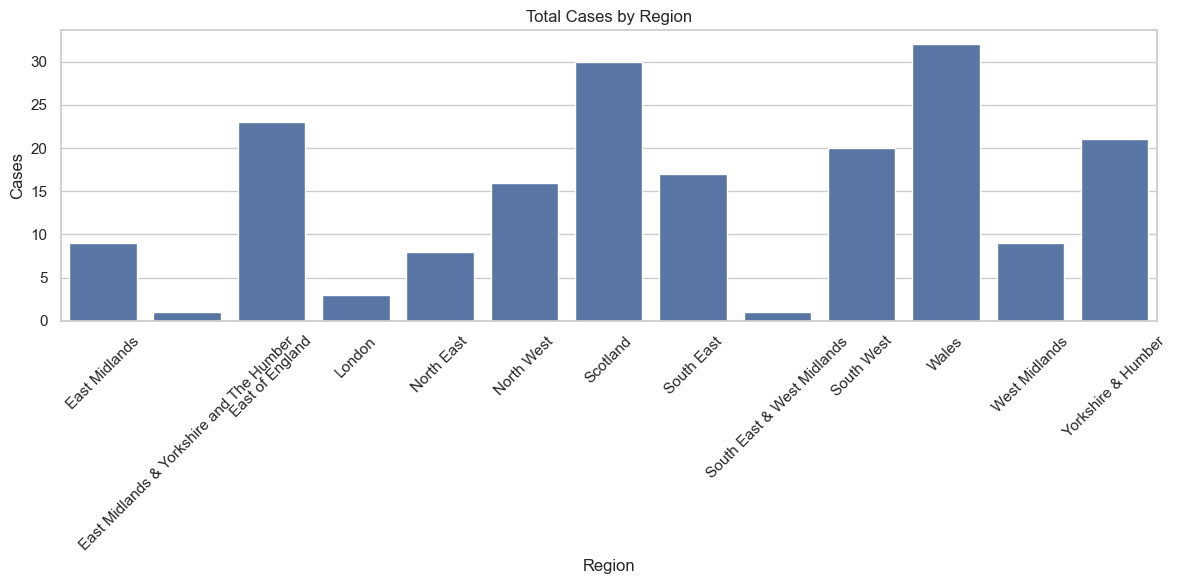

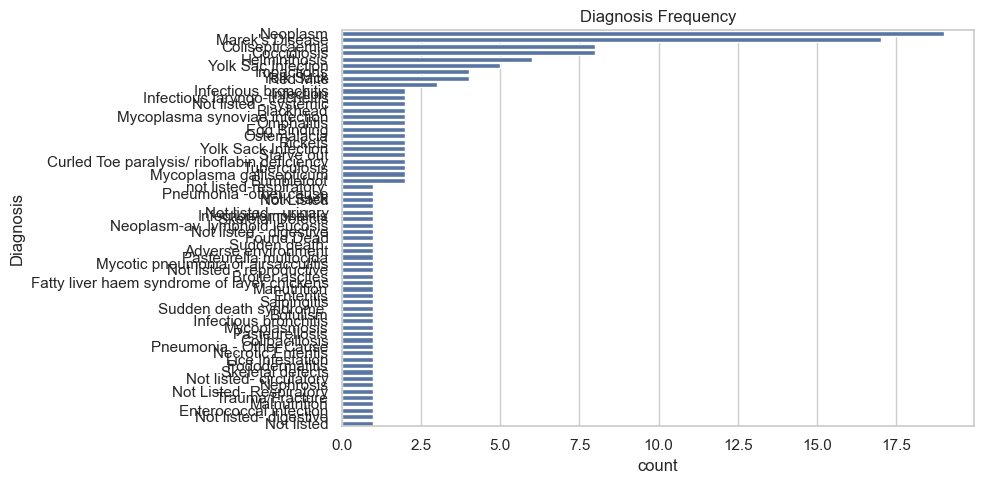

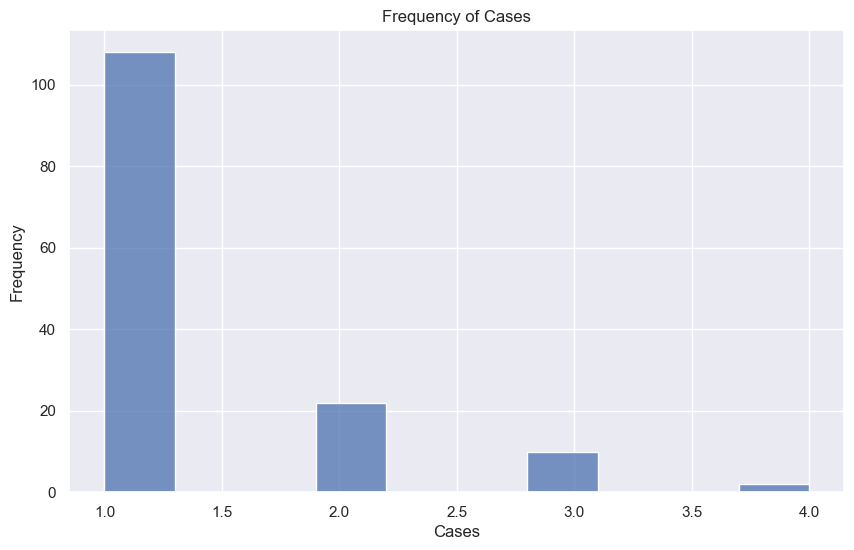

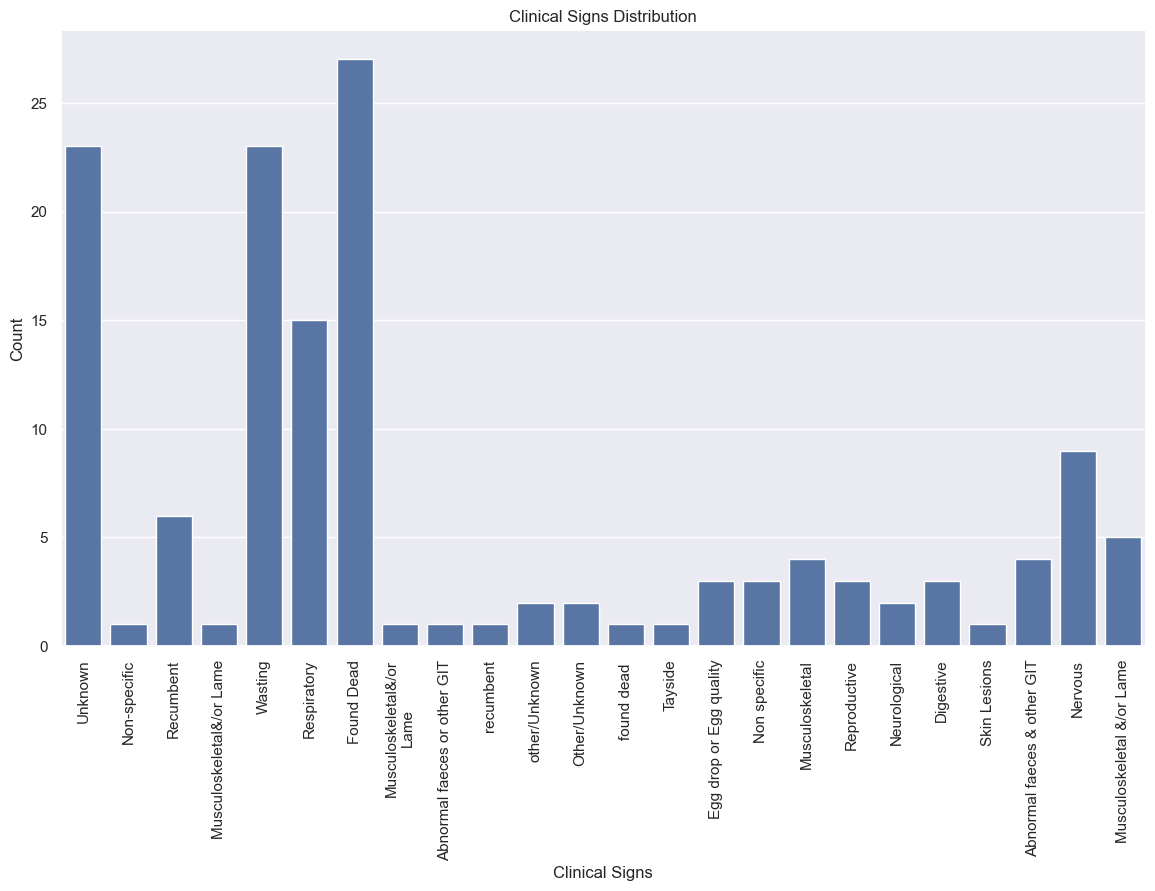

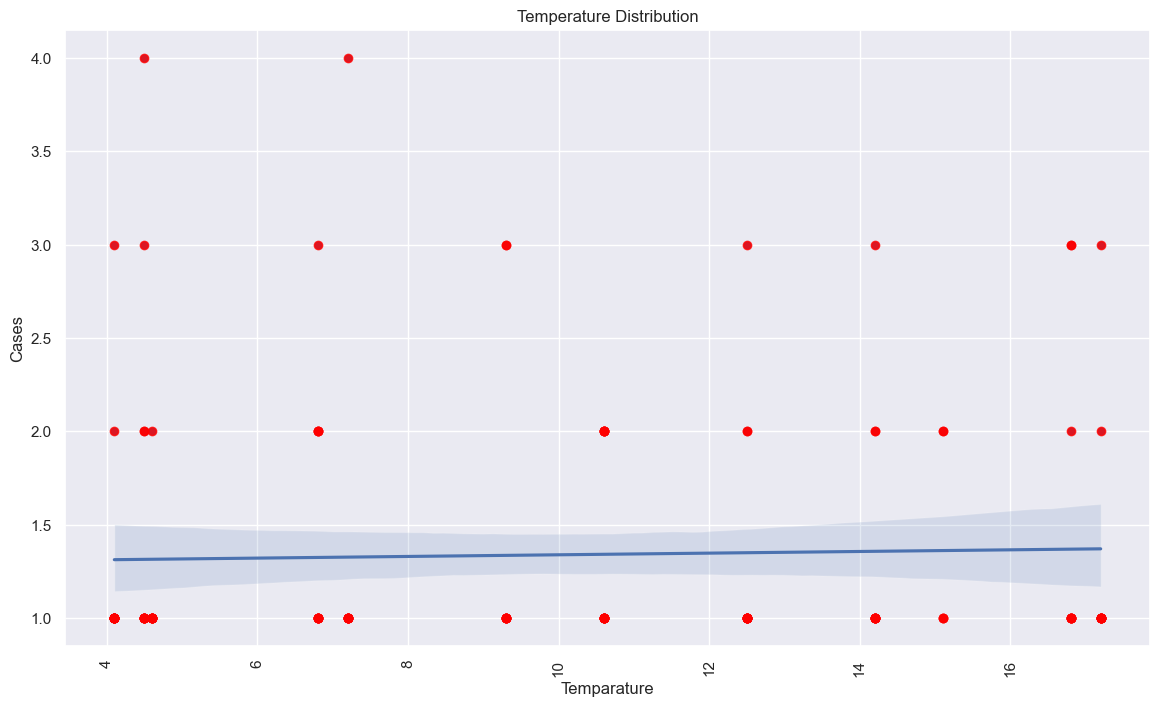

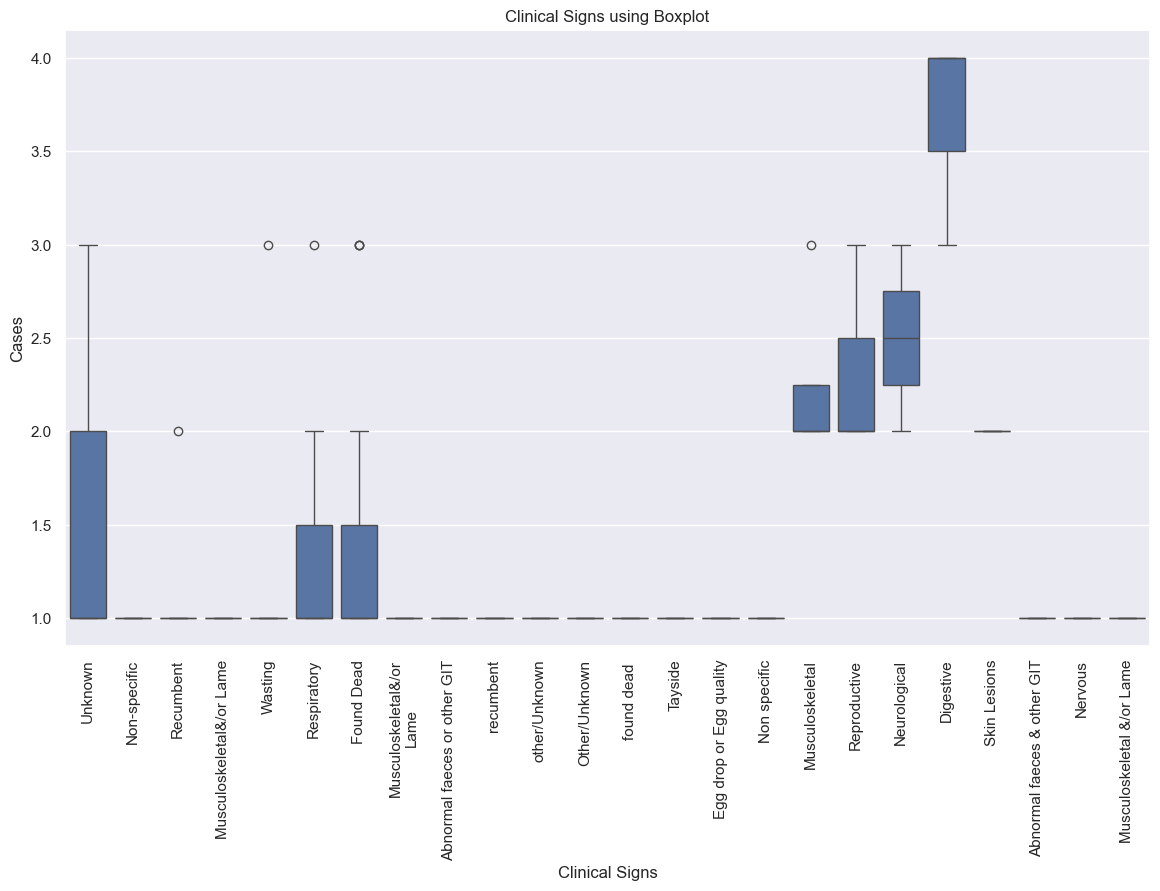

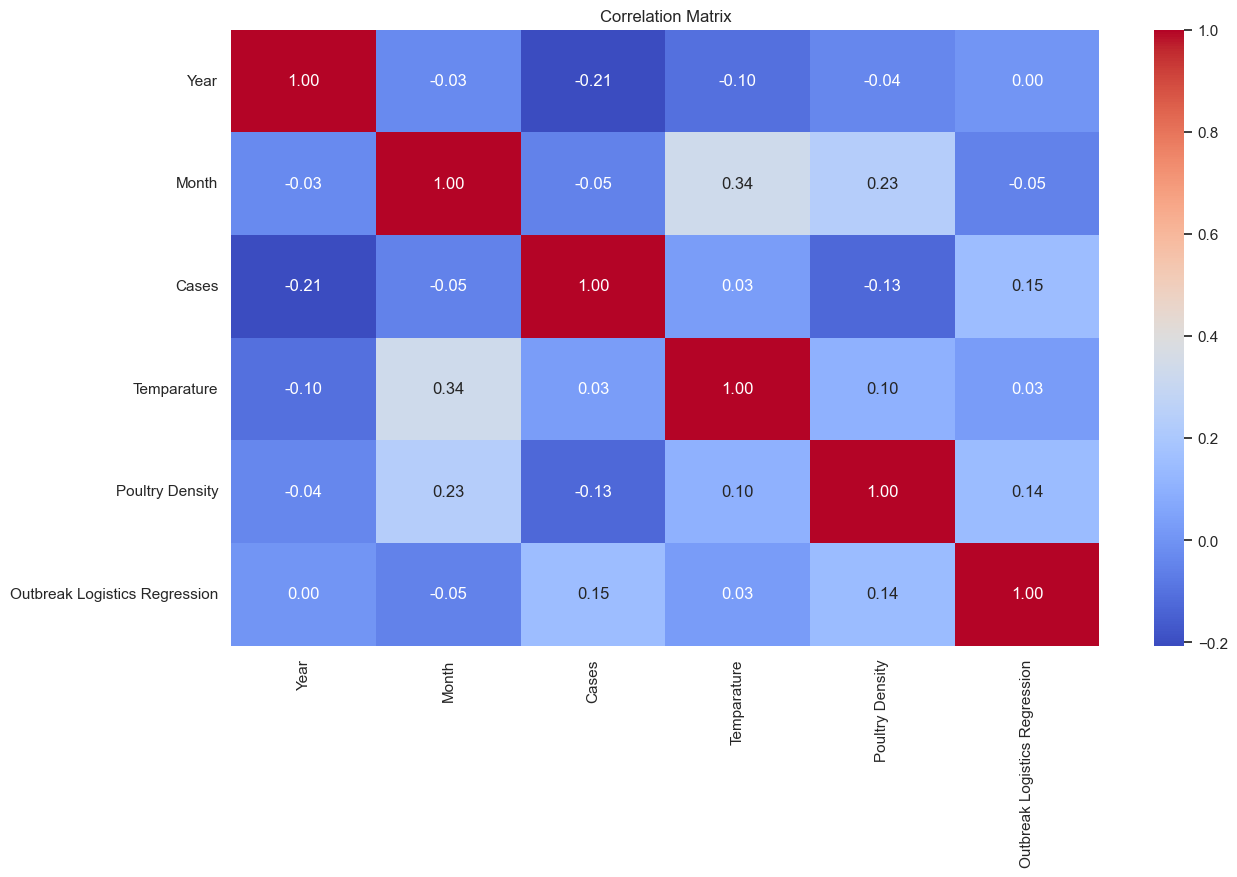

In [12]:
# Import the required libraries and reload the dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('avian_data.csv')
print(data.head())
print(data.describe())
print(data.dtypes)

# Load the dataset from a CSV file
data = pd.read_csv('avian_data.csv')
print(data.head())

# Display information about the DataFrame
print(data.info())
print(data.describe(include='all'))

# Create a new 'Date' column by combining 'Year' and 'Month'
data['Date'] = pd.to_datetime(data[['Year', 'Month']].assign(DAY=1))

# Plot the total number of cases over time
plt.figure(figsize=(12, 6))
data.groupby('Date')['Cases'].sum().plot()
plt.title('Total Cases Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Cases')
plt.grid(True)
plt.show()

# Plot total cases by region using a bar plot
plt.figure(figsize=(12, 6))
sns.barplot(data=data.groupby('Region')['Cases'].sum().reset_index(), x='Region', y='Cases')
plt.title('Total Cases by Region')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot the frequency of different diagnoses using a count plot
plt.figure(figsize=(10, 5))
sns.countplot(data=data, y='Diagnosis', order=data['Diagnosis'].value_counts().index)
plt.title('Diagnosis Frequency')
plt.tight_layout()
plt.show()

#Univariate (One variable at a time)
# Frequency on total cases (Histogram)

sns.set_style('darkgrid')
plt.figure(figsize=(10,6))
sns.histplot(data['Cases'],bins=10, kde=False)
plt.title('Frequency of Cases')
plt.xlabel('Cases')
plt.ylabel('Frequency')
plt.show()

# Clinical Signs count (Counter plot)

plt.figure(figsize=(14,8))
sns.countplot(data=data, x='Clinical Sign')
plt.title('Clinical Signs Distribution')
plt.xlabel('Clinical Signs')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()


#Bivariate
# Scatter Plot (Temperature vs Cases)
plt.figure(figsize=(14,8))
sns.scatterplot(data=data, x='Temparature', y='Cases')
sns.regplot(data=data, x='Temparature', y='Cases',scatter_kws={'color':'red'})
plt.title('Temperature Distribution')
plt.xlabel('Temparature')
plt.ylabel('Cases')
plt.xticks(rotation=90)
plt.show()


#Box Plot  (Clinical signs vs Cases)
plt.figure(figsize=(14,8))
sns.boxplot(data=data, x='Clinical Sign', y='Cases')
plt.title('Clinical Signs using Boxplot')
plt.xlabel('Clinical Signs')
plt.ylabel('Cases')
plt.xticks(rotation=90)
plt.show()

#Heatmap
numerical_data = data.select_dtypes(include=['float64','int64'])
correlation_matrix = numerical_data.corr()
plt.figure(figsize=(14,8))
sns.heatmap(data=correlation_matrix, annot=True,cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

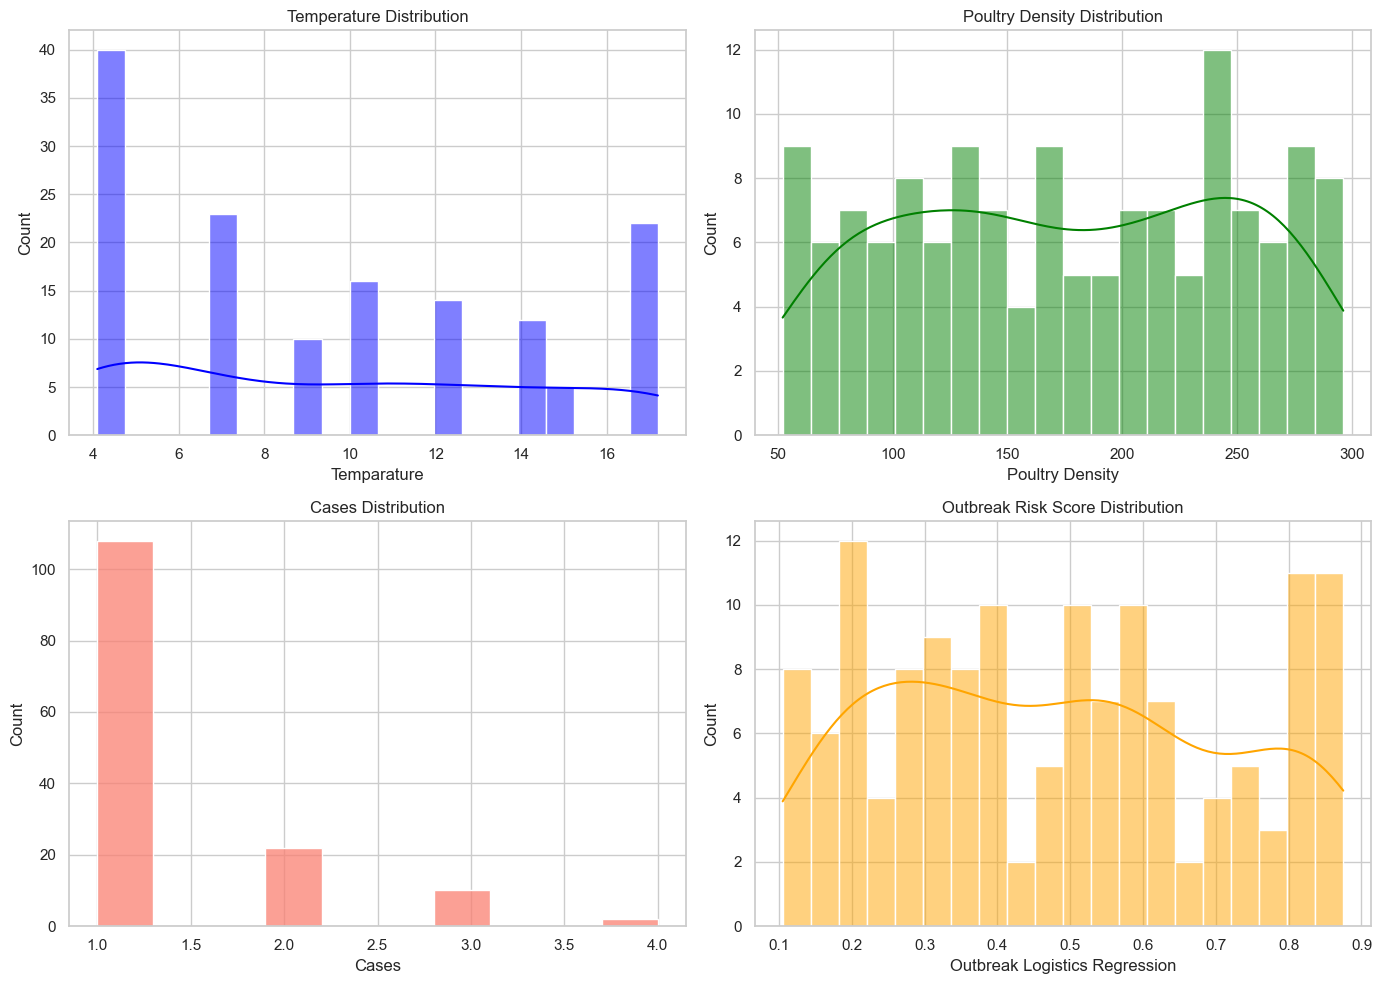

In [13]:
# Configure seaborn to use a white grid style
sns.set(style="whitegrid")

# Create subplots to visualize the distribution of numerical features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot the distribution of temperature with a histogram and kernel density estimate
sns.histplot(data['Temparature'], bins=20, kde=True, ax=axes[0, 0], color='blue')
axes[0, 0].set_title('Temperature Distribution')

# Plot the distribution of poultry density
sns.histplot(data['Poultry Density'], bins=20, kde=True, ax=axes[0, 1], color='green')
axes[0, 1].set_title('Poultry Density Distribution')

# Plot the distribution of cases without a kernel density estimate
sns.histplot(data['Cases'], bins=10, kde=False, ax=axes[1, 0], color='salmon')
axes[1, 0].set_title('Cases Distribution')

# Plot the distribution of outbreak risk scores
sns.histplot(data['Outbreak Logistics Regression'], bins=20, kde=True, ax=axes[1, 1], color='orange')
axes[1, 1].set_title('Outbreak Risk Score Distribution')

# Adjust layout to prevent overlap and display the plots
plt.tight_layout()
plt.show()

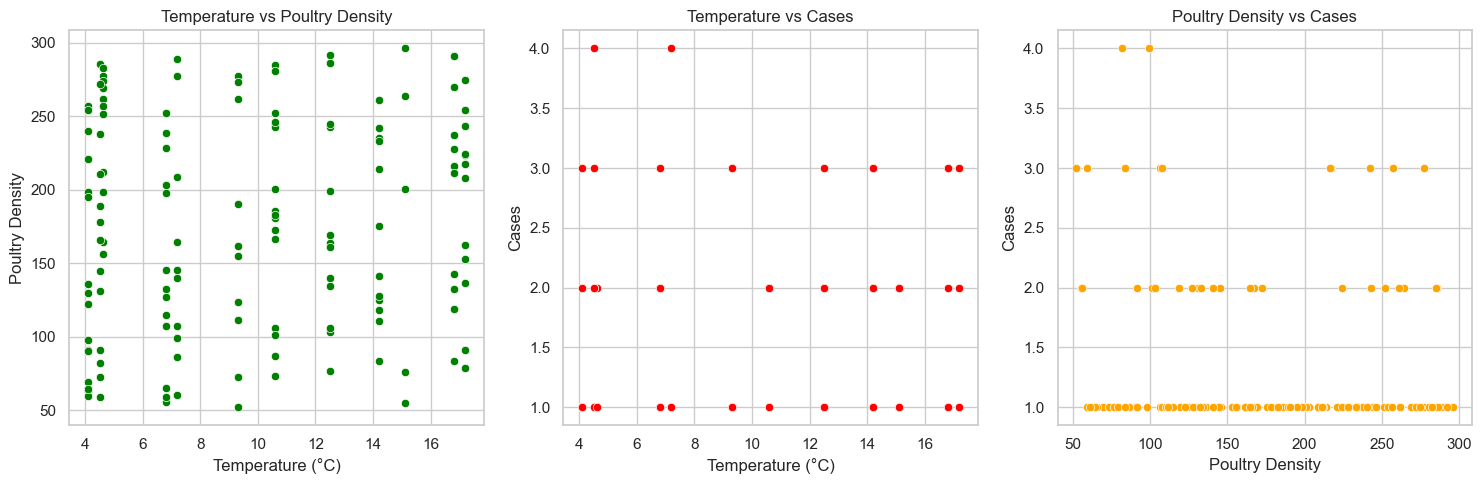

In [14]:
# Create scatter plots to analyze the relationships between key variables
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Scatter plot for Temperature against Poultry Density
sns.scatterplot(x=data['Temparature'], y=data['Poultry Density'], ax=axes[0], color='green')
axes[0].set_title('Temperature vs Poultry Density')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Poultry Density')

# Scatter plot for Temperature against Cases
sns.scatterplot(x=data['Temparature'], y=data['Cases'], ax=axes[1], color='red')
axes[1].set_title('Temperature vs Cases')
axes[1].set_xlabel('Temperature (°C)')
axes[1].set_ylabel('Cases')

# Scatter plot for Poultry Density against Cases
sns.scatterplot(x=data['Poultry Density'], y=data['Cases'], ax=axes[2], color='orange')
axes[2].set_title('Poultry Density vs Cases')
axes[2].set_xlabel('Poultry Density')
axes[2].set_ylabel('Cases')

plt.tight_layout()  # Optimize layout to avoid overlap
plt.show()  # Render the plots

# **Linear Regression & Logistic Regression Model Evaluation**

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.preprocessing import StandardScaler

# Prepare the data for modeling
# For Linear Regression, we will use 'Outbreak Logistics Regression' as the target variable
X = data[['Temparature', 'Poultry Density']]  # Features
y_linear = data['Outbreak Logistics Regression']  # Target variable for linear regression

# For Logistic Regression, we will create a binary target for 'Cases' (1 if there is an outbreak, 0 if not)
y_logistic = (data['Cases'] > 1).astype(int)  # 1 if Cases > 1, otherwise 0

# Split the data into training and testing sets (80% for training, 20% for testing)
X_train, X_test, y_train_linear, y_test_linear = train_test_split(X, y_linear, test_size=0.2, random_state=42)
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X, y_logistic, test_size=0.2, random_state=42)

# Scale the features for the regression models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Linear Regression Model
linear_reg_model = LinearRegression()
linear_reg_model.fit(X_train_scaled, y_train_linear)
y_pred_linear = linear_reg_model.predict(X_test_scaled)

# Compute Mean Squared Error for the Linear Regression model
mse = mean_squared_error(y_test_linear, y_pred_linear)

# Logistic Regression Model
log_reg_model = LogisticRegression()
log_reg_model.fit(X_train_scaled, y_train_log)
y_pred_log = log_reg_model.predict(X_test_scaled)

# Compute Accuracy for the Logistic Regression model
log_acc = accuracy_score(y_test_log, y_pred_log)

mse, log_acc

(0.04947874805844067, 0.6551724137931034)

# **Linear Regression Model Implementation**

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Prepare the dataset
X = data[['Temparature', 'Poultry Density']]  # Features
y_linear = data['Outbreak Logistics Regression']  # Target variable for linear regression

# Split the dataset into training and testing sets
X_train, X_test, y_train_linear, y_test_linear = train_test_split(X, y_linear, test_size=0.2, random_state=42)

# Scale the feature values
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit the Linear Regression model
linear_reg_model = LinearRegression()
linear_reg_model.fit(X_train_scaled, y_train_linear)

# Generate predictions and compute Mean Squared Error (MSE)
y_pred_linear = linear_reg_model.predict(X_test_scaled)
mse = mean_squared_error(y_test_linear, y_pred_linear)

print(f'Mean Squared Error (Linear Regression): {mse}')

Mean Squared Error (Linear Regression): 0.04947874805844067


# **Logistic Regression Model Implementation**

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Prepare the target variable
y_logistic = (data['Cases'] > 1).astype(int)  # Binary target variable (1 for Outbreak, 0 for No Outbreak)

# Split the dataset into training and testing subsets
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X, y_logistic, test_size=0.2, random_state=42)

# Scale the feature data
X_train_scaled = scaler.fit_transform(X_train_log)
X_test_scaled = scaler.transform(X_test_log)

# Fit the Logistic Regression model
log_reg_model = LogisticRegression()
log_reg_model.fit(X_train_scaled, y_train_log)

# Generate predictions and compute the accuracy
y_pred_log = log_reg_model.predict(X_test_scaled)
log_acc = accuracy_score(y_test_log, y_pred_log)

print(f'Accuracy of Logistic Regression: {log_acc}')

Accuracy of Logistic Regression: 0.6551724137931034


In [18]:
# Re-import required modules for modeling
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# Load the dataset again and define features and target
data = pd.read_csv("avian_data.csv")
data['Outbreak_Flag'] = (data['Outbreak Logistics Regression'] > 0.5).astype(int)

# Select features and target
features = ['Temparature', 'Poultry Density', 'Cases', 'Outbreak Logistics Regression']
X = data[features]
y = data['Outbreak_Flag']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)
y_pred_linear = (linear_model.predict(X_test_scaled) > 0.5).astype(int)
acc_linear = accuracy_score(y_test, y_pred_linear)

# Fit Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)
y_pred_logistic = log_model.predict(X_test_scaled)
acc_logistic = accuracy_score(y_test, y_pred_logistic)

# Calculate the difference
accuracy_difference = acc_logistic - acc_linear

acc_linear, acc_logistic, accuracy_difference

(0.9310344827586207, 0.9310344827586207, 0.0)

# **Statistical Test Results of t-statistic & p-value**

In [19]:
from scipy.stats import ttest_rel

# Prepare the features and target variables for modeling
features = data[['Temparature', 'Poultry Density']]  # Features

# Define the target variable for Linear Regression
target_linear = data['Outbreak Logistics Regression']  # Target for linear regression

# Create a binary target variable for Logistic Regression based on 'Cases'
target_logistic = (data['Cases'] > 1).astype(int)  # 1 if Cases > 1, otherwise 0

# Split the dataset into training and testing sets (80% for training, 20% for testing)
X_train, X_test, y_train_linear, y_test_linear = train_test_split(features, target_linear, test_size=0.2, random_state=42)
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(features, target_logistic, test_size=0.2, random_state=42)

# Standardize the feature data for the regression models
scaler = StandardScaler()
X_train_standardized = scaler.fit_transform(X_train)
X_test_standardized = scaler.transform(X_test)

# Fit the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train_standardized, y_train_linear)
predictions_linear = linear_model.predict(X_test_standardized)

# Fit the Logistic Regression model
logistic_model = LogisticRegression()
logistic_model.fit(X_train_standardized, y_train_log)
predictions_logistic = logistic_model.predict(X_test_standardized)

# Calculate the residuals for both models
residuals_linear = y_test_linear - predictions_linear
residuals_logistic = y_test_log - predictions_logistic

# Conduct a paired t-test on the residuals
t_statistic, p_value = ttest_rel(residuals_linear, residuals_logistic)

t_statistic, p_value

(np.float64(-4.311290051643703), np.float64(0.00018146219252036664))

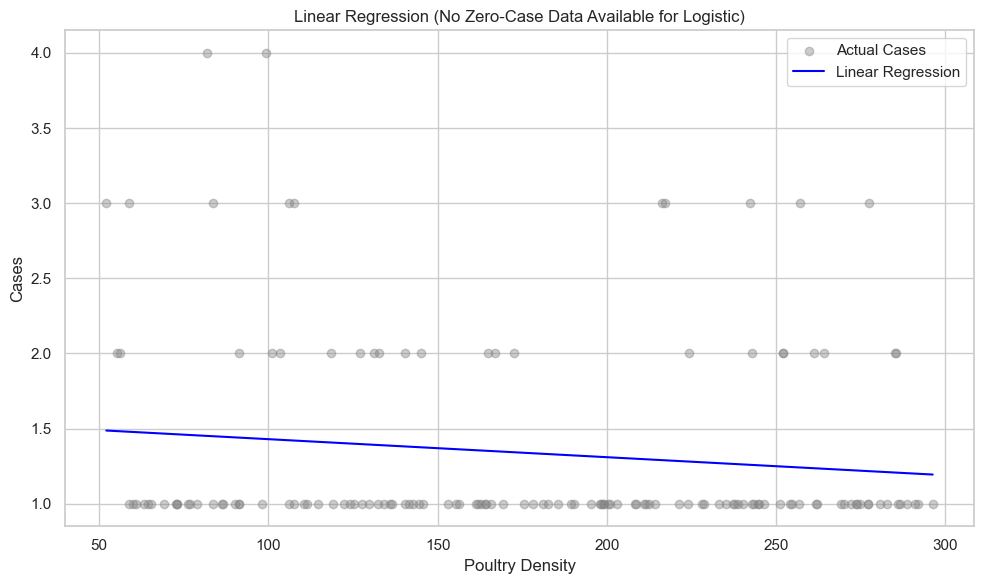

In [20]:
from scipy.stats import ttest_rel
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.preprocessing import StandardScaler

# Manually check if there are any rows with Cases == 0 in the full dataset
has_zero_cases = (data['Cases'] == 0).sum()

# Prepare graph only if zero-case rows exist
if has_zero_cases > 0:
    # Filter relevant columns and drop rows with missing values
    data = data[['Poultry Density', 'Cases']].dropna()
    X = data[['Poultry Density']].values
    y_linear = data['Cases'].values
    y_logistic = (data['Cases'] > 0).astype(int).values

    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Fit models
    lin_reg = LinearRegression().fit(X, y_linear)
    log_reg = LogisticRegression().fit(X_scaled, y_logistic)

    # Predict
    X_range = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
    X_range_scaled = scaler.transform(X_range)
    y_lin_pred = lin_reg.predict(X_range)
    y_log_pred = log_reg.predict_proba(X_range_scaled)[:, 1]

    # Plot
    plt.figure(figsize=(10, 6))
    plt.scatter(X, y_linear, alpha=0.4, label='Actual Cases', color='gray')
    plt.plot(X_range, y_lin_pred, color='blue', label='Linear Regression')
    plt.plot(X_range, y_log_pred * y_linear.max(), color='red', linestyle='--',
             label='Logistic Regression (scaled to max Cases)')
    plt.xlabel('Poultry Density')
    plt.ylabel('Cases')
    plt.title('Linear vs Logistic Regression')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    # Plot only linear regression
    data = data[['Poultry Density', 'Cases']].dropna()
    X = data[['Poultry Density']].values
    y_linear = data['Cases'].values
    lin_reg = LinearRegression().fit(X, y_linear)
    X_range = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
    y_lin_pred = lin_reg.predict(X_range)

    plt.figure(figsize=(10, 6))
    plt.scatter(X, y_linear, alpha=0.4, label='Actual Cases', color='gray')
    plt.plot(X_range, y_lin_pred, color='blue', label='Linear Regression')
    plt.xlabel('Poultry Density')
    plt.ylabel('Cases')
    plt.title('Linear Regression (No Zero-Case Data Available for Logistic)')
    plt.legend()
# Manually check if there are any rows with Cases == 0 in the full dataset
has_zero_cases = (data['Cases'] == 0).sum()

plt.grid(True)
plt.tight_layout()
plt.show()

# **Step: Import Metrics**

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report


# **Step: Evaluate Model**

In [22]:
# Get predicted probabilities for ROC-AUC
y_prob_log = log_reg_model.predict_proba(X_test_scaled)[:, 1]

# Compute the evaluation metrics
accuracy = accuracy_score(y_test_log, y_pred_log)
precision = precision_score(y_test_log, y_pred_log)
recall = recall_score(y_test_log, y_pred_log)
f1 = f1_score(y_test_log, y_pred_log)
roc_auc = roc_auc_score(y_test_log, y_prob_log)
# Output all metrics
print("Model Evaluation Metrics:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

ValueError: X has 4 features, but LogisticRegression is expecting 2 features as input.

# **Visualize the ROC Curve**

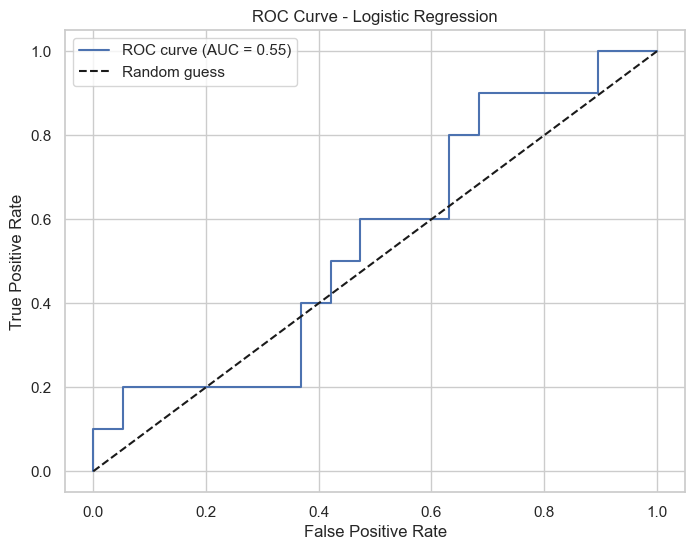

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
# Compute the false positive rates, true positive rates, and thresholds for the ROC curve
fpr, tpr, thresholds = roc_curve(y_test_log, y_prob_log)
# Create a new figure for the plot
plt.figure(figsize=(8, 6))
# Plot the ROC curve with the AUC score included in the label
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
# Add a dashed line representing random guessing
plt.plot([0, 1], [0, 1], "k--", label="Random guess")
# Set the labels for the axes
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
# Add a title to the plot
plt.title("ROC Curve - Logistic Regression")
# Include a legend and enable the grid
plt.legend()
plt.grid(True)
# Display the plot
plt.show()

# **Hyperparameter Tuning for Logistic Regression**

In [27]:
from sklearn.preprocessing import StandardScaler

# Scale the features for logistic regression
scaler = StandardScaler()
X_train_log_scaled = scaler.fit_transform(X_train_log)

# Create an instance of GridSearchCV for hyperparameter optimization
grid_search_cv = GridSearchCV(
    LogisticRegression(max_iter=1000),
    parameter_grid,
    cv=5,
    scoring='accuracy'
)

# Train the model using grid search
grid_search_cv.fit(X_train_log_scaled, y_train_log)

# Retrieve and display the best parameters and score from cross-validation
print(f"Optimal parameters: {grid_search_cv.best_params_}")
print(f"Best cross-validation accuracy: {grid_search_cv.best_score_}")

Optimal parameters: {'C': 0.001, 'penalty': 'l1', 'solver': 'liblinear'}
Best cross-validation accuracy: 0.7877470355731226


# **Cross-Validation**

In [ ]:
from sklearn.model_selection import cross_val_score

# Scale the features for logistic regression if not already done
scaler = StandardScaler()
X_train_log_scaled = scaler.fit_transform(X_train_log)

# Perform 5-fold cross-validation
cv_scores = cross_val_score(
    LogisticRegression(C=1, penalty='l2', solver='liblinear'),
    X_train_log_scaled,
    y_train_log,
    cv=5,
    scoring='accuracy'
)

print(f"Cross-validation scores: {cv_scores}")
print(f"Mean CV accuracy: {np.mean(cv_scores):.3f}")

Cross-validation scores: [0.7826087  0.7826087  0.7826087  0.81818182 0.77272727]
Mean CV accuracy: 0.788
